# 实验：transport map 与 `nis` 在三类协同机制上的对比

这个 notebook 只服务最后一组主实验：比较 `EI^{nis}`、`Syn^{nis}`、`EI^{tm}`、`Syn^{tm}` 在三类连续机制上的变化。

- `Strong synergy`
- `Moderate synergy`
- `Zero synergy`

最终只保留三部分输出：实验汇总表、四条量的对比图，以及 `Syn / EI` 比值图。


In [1]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path
from typing import Any

os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')
os.environ.setdefault('MPLCONFIGDIR', str((Path.cwd().resolve() / 'tmp' / 'matplotlib').resolve()))
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = None
for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / 'utils.py').exists():
        candidate_str = str(candidate)
        if candidate_str not in sys.path:
            sys.path.insert(0, candidate_str)
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    raise RuntimeError('Could not locate project root from current working directory.')

from utils import jacobian_uniform_box_total_synergy_for_dynamics
from yrd.transport_map import summarize_two_source_synergy_transport_map

SEED = 11
RNG = np.random.default_rng(SEED)


## 实验设定

三类机制共享同一套输入分布：

\[
Q_1^n, Q_2^n, Q_3^n \sim \mathrm{Uniform}[-L/2, L/2].
\]

区别只在于目标动力学 `Q_1^{n+1}`：

- `Strong synergy`：目标主要由乘积项驱动
- `Moderate synergy`：加性项和乘积项并存
- `Zero synergy`：目标只依赖单一源变量

下面的代码 cell 只负责：定义案例、采样一个实验批次、调用已有模块计算 `EI` / `Syn`、然后汇总结果。


In [2]:
CASE_SPECS = {
    'strong': {
        'title': 'Strong synergy',
        'q1_mean_fn': lambda q2, q3: np.sin(q2 * q3),
        'q1_noise_std': 0.001,
    },
    'moderate': {
        'title': 'Moderate synergy',
        'q1_mean_fn': lambda q2, q3: 0.4 * (q2 + q3) + 0.25 * np.sin(q2 * q3),
        'q1_noise_std': 0.08,
    },
    'zero': {
        'title': 'Zero synergy',
        'q1_mean_fn': lambda q2, q3: 0.8 * q2,
        'q1_noise_std': 0.001,
    },
}
CASE_ORDER = ('strong', 'moderate', 'zero')
UNIFORM_INTERVENTION_L_VALUES = (0.8, 1.6, 3.2, 6.4, 12.8, 25.6, 51.2, 102.4)
N_SAMPLES = 2500
REPEATS = 3
JACOBIAN_MC_SAMPLES = 4096


def simulate_uniform_case_intervention(
    *,
    case_key: str,
    n_samples: int = N_SAMPLES,
    L: float = 2.0,
    seed: int = 0,
) -> pd.DataFrame:
    if case_key not in CASE_SPECS:
        raise KeyError(f'Unknown case_key: {case_key}')
    rng = np.random.default_rng(seed)
    half = float(L) / 2.0
    q1_t = rng.uniform(-half, half, size=n_samples)
    q2_t = rng.uniform(-half, half, size=n_samples)
    q3_t = rng.uniform(-half, half, size=n_samples)
    w1 = rng.normal(size=n_samples)
    w2 = rng.normal(size=n_samples)
    w3 = rng.normal(size=n_samples)
    q1_mean = CASE_SPECS[case_key]['q1_mean_fn'](q2_t, q3_t)
    q1_next = q1_mean + float(CASE_SPECS[case_key]['q1_noise_std']) * w1
    q2_next = 0.5 * q2_t + 0.1 * w2
    q3_next = 0.5 * q3_t + 0.1 * w3
    return pd.DataFrame(
        {
            'case_key': case_key,
            'q1_t': q1_t,
            'q2_t': q2_t,
            'q3_t': q3_t,
            'q1_next': q1_next,
            'q2_next': q2_next,
            'q3_next': q3_next,
        }
    )


def make_case_mean_dynamics(case_key: str):
    q1_mean_fn = CASE_SPECS[case_key]['q1_mean_fn']

    def dynamics(x: np.ndarray) -> np.ndarray:
        array = np.asarray(x, dtype=float).reshape(-1)
        return np.array(
            [
                q1_mean_fn(array[1], array[2]),
                0.5 * array[1],
                0.5 * array[2],
            ],
            dtype=float,
        )

    return dynamics


def case_output_covariance(case_key: str) -> np.ndarray:
    q1_noise_std = float(CASE_SPECS[case_key]['q1_noise_std'])
    return np.diag([q1_noise_std**2, 0.1**2, 0.1**2])


def estimate_nis_target_metrics(*, case_key: str, L: float, n_mc_samples: int, seed: int) -> dict[str, float]:
    half = float(L) / 2.0
    bounds = np.array([[-half, half], [-half, half], [-half, half]], dtype=float)
    summary = jacobian_uniform_box_total_synergy_for_dynamics(
        make_case_mean_dynamics(case_key),
        state_dim=3,
        source_partition=[[1], [2]],
        target_indices=[0],
        output_covariance=case_output_covariance(case_key),
        intervention_bound=bounds,
        n_mc_samples=n_mc_samples,
        seed=seed,
    )
    nis_ei = np.log(float(L)) - 0.5 * np.log(2.0 * np.pi * np.e) + 0.5 * float(summary['mean_log_pdet_whole'])
    return {'nis_ei': float(nis_ei), 'nis_syn': float(summary['syn_total'])}


def estimate_tm_target_metrics(df: pd.DataFrame) -> dict[str, float]:
    summary = summarize_two_source_synergy_transport_map(
        df[['q2_t']].to_numpy(),
        df[['q3_t']].to_numpy(),
        df[['q1_next']].to_numpy(),
    )
    return {
        'tm_ei': float(summary['joint_ei']),
        'tm_syn': float(summary['syn']),
        'tm_single_q2': float(summary['left_ei']),
        'tm_single_q3': float(summary['right_ei']),
    }


def compare_uniform_intervention_nis_vs_transport(
    *,
    case_order: tuple[str, ...] = CASE_ORDER,
    L_values: tuple[float, ...] = UNIFORM_INTERVENTION_L_VALUES,
    n_samples: int = N_SAMPLES,
    repeats: int = REPEATS,
    seed: int = SEED,
    jacobian_mc_samples: int = JACOBIAN_MC_SAMPLES,
) -> pd.DataFrame:
    rows: list[dict[str, float | int | str]] = []
    for case_index, case_key in enumerate(case_order):
        for L in L_values:
            for repeat in range(repeats):
                run_seed = seed + 1000 * case_index + repeat
                df = simulate_uniform_case_intervention(
                    case_key=case_key,
                    n_samples=n_samples,
                    L=L,
                    seed=run_seed,
                )
                nis_metrics = estimate_nis_target_metrics(
                    case_key=case_key,
                    L=L,
                    n_mc_samples=jacobian_mc_samples,
                    seed=run_seed,
                )
                tm_metrics = estimate_tm_target_metrics(df)
                rows.append(
                    {
                        'case_key': case_key,
                        'case_title': CASE_SPECS[case_key]['title'],
                        'q1_noise_std': float(CASE_SPECS[case_key]['q1_noise_std']),
                        'L': float(L),
                        'repeat': int(repeat),
                        'nis_ei': nis_metrics['nis_ei'],
                        'nis_syn': nis_metrics['nis_syn'],
                        'tm_ei': tm_metrics['tm_ei'],
                        'tm_syn': tm_metrics['tm_syn'],
                        'tm_single_q2': tm_metrics['tm_single_q2'],
                        'tm_single_q3': tm_metrics['tm_single_q3'],
                    }
                )
    return pd.DataFrame(rows)


def summarize_uniform_intervention_nis_vs_transport(results_df: pd.DataFrame) -> pd.DataFrame:
    summary = (
        results_df.groupby(['case_key', 'case_title', 'q1_noise_std', 'L'], as_index=False)
        .agg(
            nis_ei_mean=('nis_ei', 'mean'),
            nis_syn_mean=('nis_syn', 'mean'),
            tm_ei_mean=('tm_ei', 'mean'),
            tm_syn_mean=('tm_syn', 'mean'),
            tm_single_q2_mean=('tm_single_q2', 'mean'),
            tm_single_q3_mean=('tm_single_q3', 'mean'),
        )
        .sort_values(['case_key', 'L'])
        .reset_index(drop=True)
    )
    summary['nis_syn_ratio'] = np.where(
        np.abs(summary['nis_ei_mean']) > 1e-12,
        summary['nis_syn_mean'] / summary['nis_ei_mean'],
        np.nan,
    )
    summary['tm_syn_ratio'] = np.where(
        np.abs(summary['tm_ei_mean']) > 1e-12,
        summary['tm_syn_mean'] / summary['tm_ei_mean'],
        np.nan,
    )
    return summary


uniform_comparison_results = compare_uniform_intervention_nis_vs_transport()
uniform_comparison_summary = summarize_uniform_intervention_nis_vs_transport(uniform_comparison_results)
uniform_comparison_summary


,case_key,case_title,q1_noise_std,L,nis_ei_mean,nis_syn_mean,tm_ei_mean,tm_syn_mean,tm_single_q2_mean,tm_single_q3_mean,nis_syn_ratio,tm_syn_ratio
0,moderate,Moderate synergy,0.080,0.8,0.314506,-0.396082,0.643629,0.200145,0.222418,0.221066,-1.259378,0.310964
1,moderate,Moderate synergy,0.080,1.6,1.007548,0.621764,1.238323,0.657934,0.290574,0.289815,0.617106,0.531311
2,moderate,Moderate synergy,0.080,3.2,1.706000,1.907386,1.796824,1.195180,0.301144,0.300500,1.118046,0.665163
3,moderate,Moderate synergy,0.080,6.4,2.444475,3.368838,1.733097,1.072079,0.323038,0.337980,1.378144,0.618591
4,moderate,Moderate synergy,0.080,12.8,3.444002,4.984854,2.383049,1.699837,0.337140,0.346072,1.447402,0.713303
5,moderate,Moderate synergy,0.080,25.6,4.646646,6.842723,3.072438,2.382927,0.342065,0.347445,1.472616,0.775582
6,moderate,Moderate synergy,0.080,51.2,5.948563,8.824877,3.771032,3.079930,0.342003,0.349098,1.483531,0.816734
7,moderate,Moderate synergy,0.080,102.4,7.036079,10.600066,4.461019,3.769557,0.342116,0.349347,1.506530,0.844999
8,strong,Strong synergy,0.001,0.8,0.927919,-0.328533,3.762528,3.761198,0.001124,0.000206,-0.354054,0.999646
9,strong,Strong synergy,0.001,1.6,0.927046,0.338727,4.102161,4.100860,0.001098,0.000202,0.365383,0.999683


(<Figure size 1600x480 with 3 Axes>, <Figure size 1600x480 with 3 Axes>)

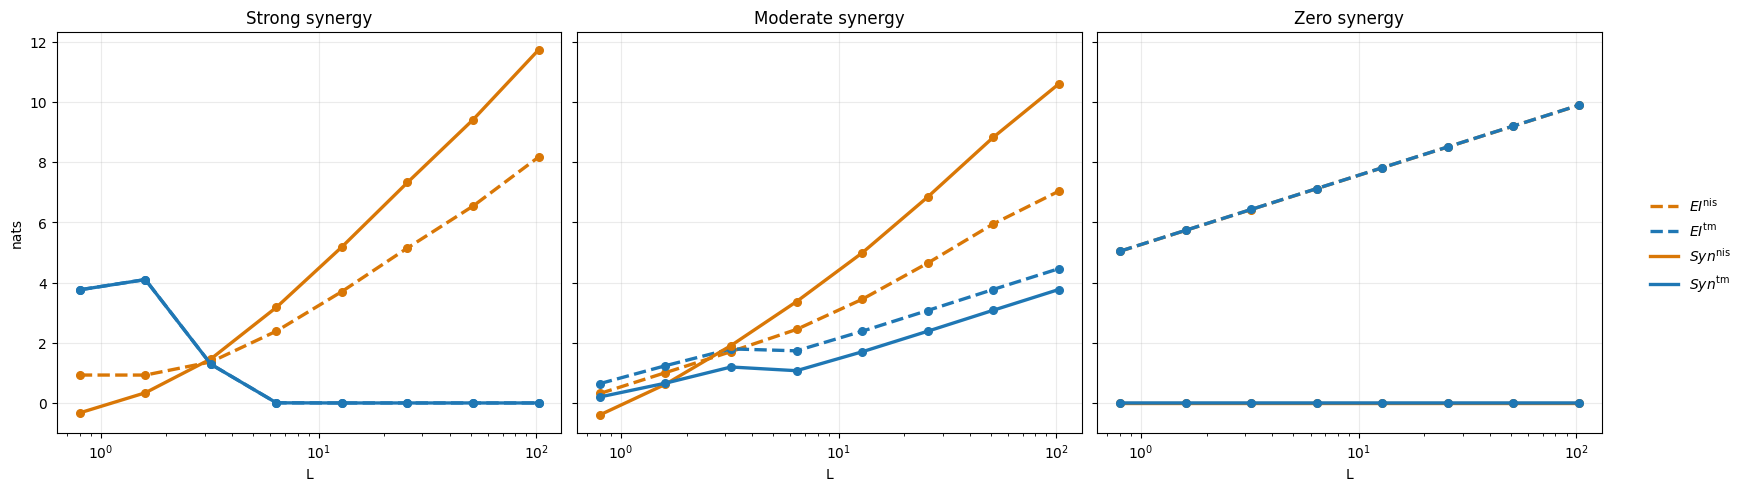

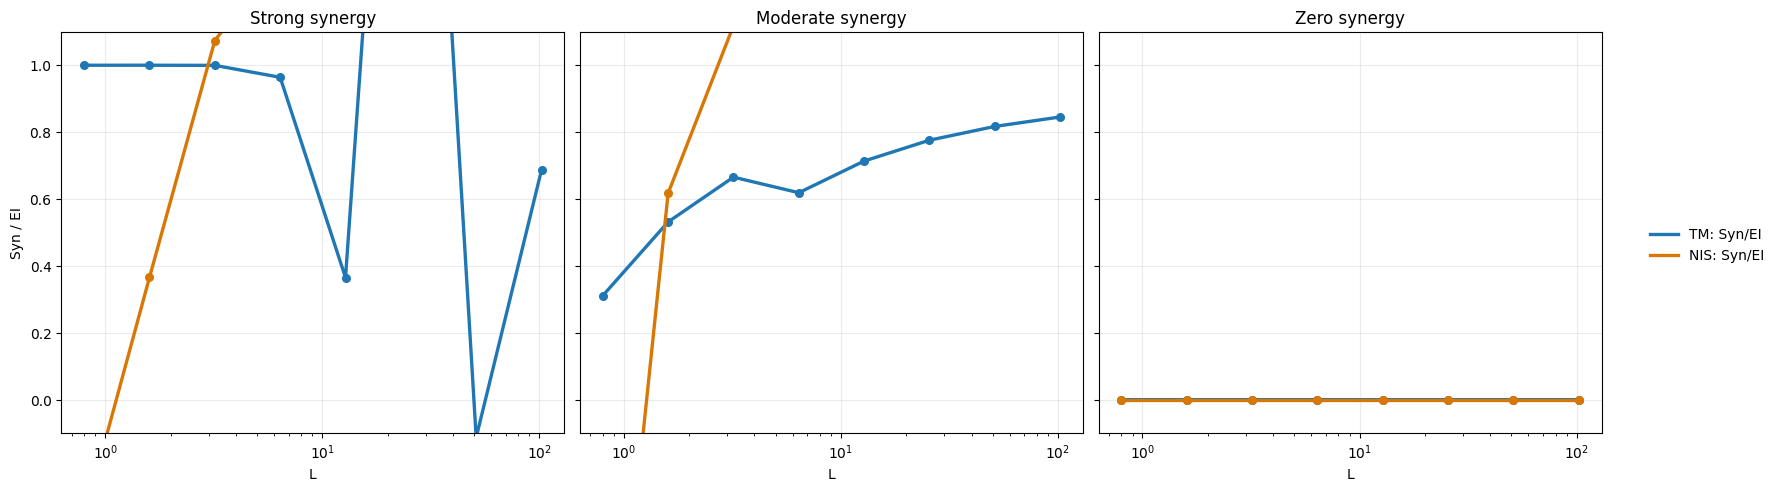

In [3]:
def plot_uniform_intervention_nis_vs_transport(summary_df: pd.DataFrame) -> tuple[Any, Any]:
    from matplotlib.lines import Line2D

    plot_df = summary_df.copy()
    color_nis = '#d97706'
    color_tm = '#1f77b4'
    line_width = 2.4
    marker_size = 5.5

    combined_fig, combined_axes = plt.subplots(
        1,
        len(CASE_ORDER),
        figsize=(16.0, 4.8),
        constrained_layout=True,
        sharey=True,
    )
    ratio_fig, ratio_axes = plt.subplots(
        1,
        len(CASE_ORDER),
        figsize=(16.0, 4.8),
        constrained_layout=True,
        sharey=True,
    )

    if len(CASE_ORDER) == 1:
        combined_axes = [combined_axes]
        ratio_axes = [ratio_axes]

    for idx, case_key in enumerate(CASE_ORDER):
        case_df = plot_df.loc[plot_df['case_key'] == case_key].sort_values('L')
        title = CASE_SPECS[case_key]['title']

        combined_axes[idx].plot(case_df['L'], case_df['nis_ei_mean'], marker='o', markersize=marker_size, linewidth=line_width, linestyle='--', color=color_nis)
        combined_axes[idx].plot(case_df['L'], case_df['tm_ei_mean'], marker='o', markersize=marker_size, linewidth=line_width, linestyle='--', color=color_tm)
        combined_axes[idx].plot(case_df['L'], case_df['nis_syn_mean'], marker='o', markersize=marker_size, linewidth=line_width, linestyle='-', color=color_nis)
        combined_axes[idx].plot(case_df['L'], case_df['tm_syn_mean'], marker='o', markersize=marker_size, linewidth=line_width, linestyle='-', color=color_tm)
        combined_axes[idx].set_title(title)
        combined_axes[idx].set_xlabel('L')
        combined_axes[idx].set_xscale('log')
        combined_axes[idx].grid(alpha=0.25)
        if idx == 0:
            combined_axes[idx].set_ylabel('nats')

        ratio_axes[idx].plot(case_df['L'], case_df['tm_syn_ratio'], marker='o', markersize=marker_size, linewidth=line_width, color=color_tm)
        ratio_axes[idx].plot(case_df['L'], case_df['nis_syn_ratio'], marker='o', markersize=marker_size, linewidth=line_width, color=color_nis)
        ratio_axes[idx].set_title(title)
        ratio_axes[idx].set_xlabel('L')
        ratio_axes[idx].set_xscale('log')
        ratio_axes[idx].set_ylim(-0.1, 1.1)
        ratio_axes[idx].grid(alpha=0.25)
        if idx == 0:
            ratio_axes[idx].set_ylabel('Syn / EI')

    combined_handles = [
        Line2D([0], [0], color=color_nis, linestyle='--', linewidth=line_width, label=r'$EI^{\mathrm{nis}}$'),
        Line2D([0], [0], color=color_tm, linestyle='--', linewidth=line_width, label=r'$EI^{\mathrm{tm}}$'),
        Line2D([0], [0], color=color_nis, linestyle='-', linewidth=line_width, label=r'$Syn^{\mathrm{nis}}$'),
        Line2D([0], [0], color=color_tm, linestyle='-', linewidth=line_width, label=r'$Syn^{\mathrm{tm}}$'),
    ]
    ratio_handles = [
        Line2D([0], [0], color=color_tm, linestyle='-', linewidth=line_width, label='TM: Syn/EI'),
        Line2D([0], [0], color=color_nis, linestyle='-', linewidth=line_width, label='NIS: Syn/EI'),
    ]
    combined_fig.legend(combined_handles, [handle.get_label() for handle in combined_handles], loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
    ratio_fig.legend(ratio_handles, [handle.get_label() for handle in ratio_handles], loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)

    output_dir = PROJECT_ROOT / 'fig' / 'transport_map_mutual_information'
    output_dir.mkdir(parents=True, exist_ok=True)
    combined_path = output_dir / 'nis_transport_combined_cases.png'
    ratio_path = output_dir / 'nis_transport_ratio_cases.png'
    summary_path = output_dir / 'nis_transport_case_summary.csv'
    manifest_path = output_dir / 'figure_manifest.json'

    combined_fig.savefig(combined_path, dpi=220, bbox_inches='tight')
    ratio_fig.savefig(ratio_path, dpi=220, bbox_inches='tight')
    plot_df.to_csv(summary_path, index=False)
    manifest_path.write_text(
        json.dumps(
            {
                'notebook': 'exp/tm_vs_nis.ipynb',
                'figures': [combined_path.name, ratio_path.name],
                'summary_csv': summary_path.name,
            },
            ensure_ascii=False,
            indent=2,
        ),
        encoding='utf-8',
    )
    return combined_fig, ratio_fig


plot_uniform_intervention_nis_vs_transport(uniform_comparison_summary)


## 如何解读这组结果

- `Strong synergy` 中，`Syn^{tm}` 和 `Syn^{nis}` 都应明显为正，说明目标主要依赖联合状态。
- `Moderate synergy` 中，协同仍为正，但规模弱于 `Strong synergy`，说明加性项开始分走一部分可由单源解释的信息。
- `Zero synergy` 中，`Syn` 应接近 0，因为目标本质上只依赖单一来源。
- `Syn / EI` 图把“协同占总信息的比例”单独拉出来，更方便比较不同 `L` 下两种估计口径的结构差异。
